<a href="https://colab.research.google.com/github/Ayushi-369/FlyrankAi-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ayushi-369/FlyrankAi-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Load data
path = (
    "../../data/raw/content_refresh_anonymized.csv"
    if os.path.exists("../../data/raw/content_refresh_anonymized.csv")
    else "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
)
df = pd.read_csv(path)

# 2. Prep data and train model (using same logic as previous weeks)
features = ["content_age_days", "days_since_last_update", "avg_position", "ctr", "engagement_rate"]
df_clean = df.dropna(subset=features + ["freshness_tier"]).copy()
target_mapping = {"181+": 1, "91-180": 1, "31-90": 0, "0-30": 0}
X = df_clean[features]
y = df_clean["freshness_tier"].map(target_mapping).fillna(0)

# Train full model for the playbook
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight="balanced", random_state=42)
rf_model.fit(X, y)

# 3. Generate probabilities and build the queue
df_clean['refresh_probability'] = rf_model.predict_proba(X)[:, 1]
# Only keep pages the model flags as needing a refresh (prob > 0.5)
action_queue = df_clean[df_clean['refresh_probability'] > 0.5].copy()
action_queue = action_queue.sort_values(by='refresh_probability', ascending=False)

# 4. Generate Human-Readable Reason Codes
def get_reason(row):
    reasons = []
    if row['content_age_days'] > 365: reasons.append("Stale Age (>1yr)")
    if row['avg_position'] > 10: reasons.append("Position Decay")
    if row['ctr'] < 0.02: reasons.append("Low CTR")
    return " + ".join(reasons) if reasons else "Complex Pattern Match"

action_queue['reason_code'] = action_queue.apply(get_reason, axis=1)

print(f"✅ Generated action queue with {len(action_queue)} candidates.")
display(action_queue[['content_id', 'refresh_probability', 'reason_code', 'content_age_days', 'avg_position']].head())

✅ Generated action queue with 9345 candidates.


,content_id,refresh_probability,reason_code,content_age_days,avg_position
10578,content_bba7a7a249b2,0.984343,Position Decay + Low CTR,286,41.2
27053,content_d6cb79fc2e17,0.984343,Position Decay,236,33.6
27050,content_91a3e174bfce,0.984343,Position Decay,236,16.9
29918,content_7b18abfa6fe3,0.984343,Position Decay,287,38.9
23333,content_7cc2fac8e32f,0.984343,Position Decay,299,27.7


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use:

This model output acts strictly as a decision-support queue for human content editors. It provides a directional, ranked list of pages that historically match the profile of traffic-decayed content likely to benefit from a refresh. It is designed to prioritize editorial bandwidth, not to replace it.

Known Limits:

False Positives on Evergreen Content: The model occasionally flags older pages with naturally stable, low-engagement traffic as "decaying."

Context Blindness: The model measures numerical decay but cannot read the actual page content to know why it decayed (e.g., a competitor released a better guide, or the search intent fundamentally shifted).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

The Human-in-the-Loop Requirement:

An editor must review every flagged page before rewriting. The model suggests where to look; the human decides what to do.

The No-Go List (Do NOT automate or rewrite):

Legal & Compliance Pages: Terms of Service, Privacy Policies, and disclaimers.

Brand / Navigational Hubs: Homepages or "Contact Us" pages (traffic drops here usually indicate a brand issue, not a content freshness issue).

Time-Locked Content: News articles, press releases, or event announcements anchored to a specific past date.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring Strategy:

Metric to Watch: The out-of-sample precision score. We will audit a random sample of 50 editor-reviewed recommendations monthly to see how often the model's recommendation aligned with the editor's judgment.

Retrain Triggers:

Time-based: Re-fit the model on fresh data every quarter (90 days) to capture changing Google algorithm updates.

Performance-based: If the monthly sampled precision drops below the Week 4 heuristic baseline, trigger an immediate retrain and feature audit.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

✅ Exported action queue to ../outputs/action_queue.csv
✅ Exported playbook figure to ../figures/reason_codes_chart.png


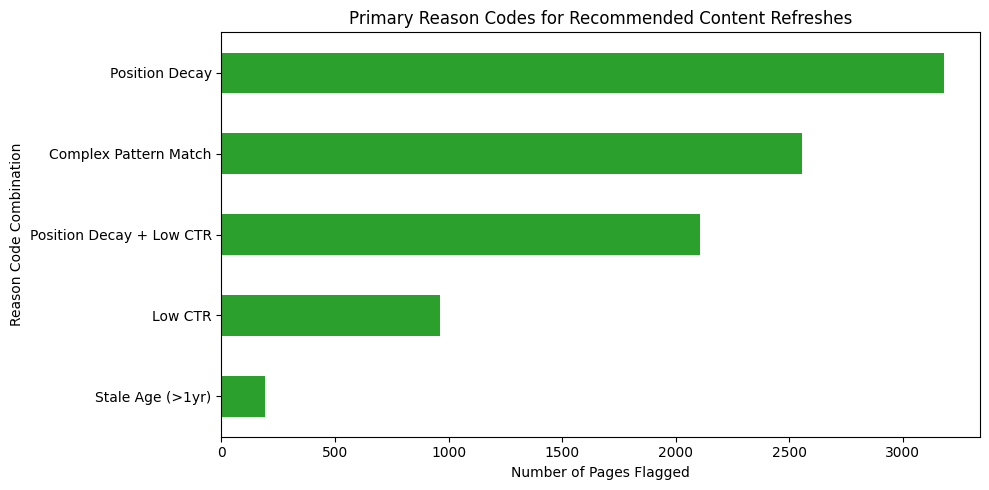

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

# 1. Ensure output directories exist relative to the notebook's location
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# 2. Export the ranked queue (Excluded from Git by CI leak-guard)
queue_export_path = "../outputs/action_queue.csv"
action_queue[['content_id', 'refresh_probability', 'reason_code', 'content_age_days', 'avg_position']].to_csv(queue_export_path, index=False)
print(f"✅ Exported action queue to {queue_export_path}")

# 3. Create and export a figure (Top Reason Codes) for the paper
plt.figure(figsize=(10, 5))
reason_counts = action_queue['reason_code'].value_counts().head(5)
reason_counts.sort_values().plot(kind='barh', color='#2ca02c')
plt.title("Primary Reason Codes for Recommended Content Refreshes")
plt.xlabel("Number of Pages Flagged")
plt.ylabel("Reason Code Combination")
plt.tight_layout()

fig_export_path = "../figures/reason_codes_chart.png"
plt.savefig(fig_export_path, dpi=300)
print(f"✅ Exported playbook figure to {fig_export_path}")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.